# Week 4 - Maryi Tatiana Palacios Giraldo

In [16]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

# ε-greedy

In [17]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice(Q.shape[1])
    else:
        return np.argmax(Q[state])

# SARSA

In [18]:
def run_sarsa(env, episodes, alpha, gamma, epsilon):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_per_episode = []

    for _ in range(episodes):
        state, _ = env.reset()
        action = epsilon_greedy(Q, state, epsilon)
        total_reward = 0
        done = False

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if not done:
                next_action = epsilon_greedy(Q, next_state, epsilon)
                target = reward + gamma * Q[next_state, next_action]
            else:
                target = reward

            Q[state, action] += alpha * (target - Q[state, action])

            state = next_state
            action = next_action if not done else None
            total_reward += reward

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode

# Q-learning

In [19]:
def run_q_learning(env, episodes, alpha, gamma, epsilon):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_per_episode = []

    for _ in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = epsilon_greedy(Q, state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if not done:
                target = reward + gamma * np.max(Q[next_state])
            else:
                target = reward

            Q[state, action] += alpha * (target - Q[state, action])

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode

# MULTIPLE SEEDS (30)

In [20]:
def run_experiment(algo, env_name, episodes=500, seeds=30):
    all_rewards = []

    for seed in range(seeds):
        env = gym.make(env_name)
        np.random.seed(seed)

        if algo == "sarsa":
            _, rewards = run_sarsa(env, episodes, 0.1, 0.99, 0.1)
        else:
            _, rewards = run_q_learning(env, episodes, 0.1, 0.99, 0.1)

        all_rewards.append(rewards)

    return np.array(all_rewards)

# RUN

In [21]:
env_name = "CliffWalking-v0"

sarsa_rewards = run_experiment("sarsa", env_name)
q_rewards = run_experiment("q", env_name)

# MEAN + 95% CI

In [22]:
def compute_stats(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    ci = 1.96 * std / np.sqrt(data.shape[0])
    return mean, ci

sarsa_mean, sarsa_ci = compute_stats(sarsa_rewards)
q_mean, q_ci = compute_stats(q_rewards)

# PLOT

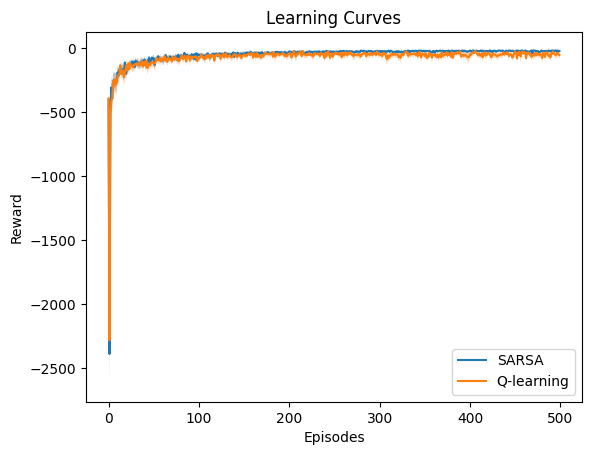

In [23]:
plt.figure()
plt.plot(sarsa_mean, label="SARSA")
plt.fill_between(range(len(sarsa_mean)),
                 sarsa_mean - sarsa_ci,
                 sarsa_mean + sarsa_ci,
                 alpha=0.3)

plt.plot(q_mean, label="Q-learning")
plt.fill_between(range(len(q_mean)),
                 q_mean - q_ci,
                 q_mean + q_ci,
                 alpha=0.3)

plt.legend()
plt.title("Learning Curves")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.show()

- From the results, both SARSA and Q-learning improve significantly over time,
moving from very low rewards at the beginning to near-optimal performance.

- Q-learning appears to converge slightly faster and reaches marginally higher rewards,
indicating it learns a more optimal policy.

- SARSA, while slightly slower, shows smoother and more stable learning behavior,
suggesting it is less sensitive to risky exploration.

# HEATMAP (Value function)

In [32]:
def plot_heatmap(Q, env):
    V = np.max(Q, axis=1) 
    grid = V.reshape((4, 12))
    
    plt.figure()
    plt.imshow(grid)
    plt.title("Value Function Heatmap")
    plt.colorbar()
    plt.show()
    

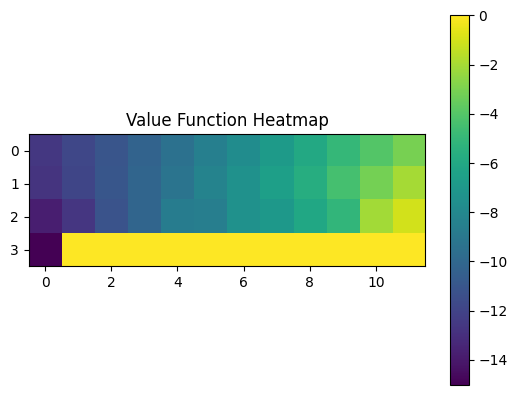

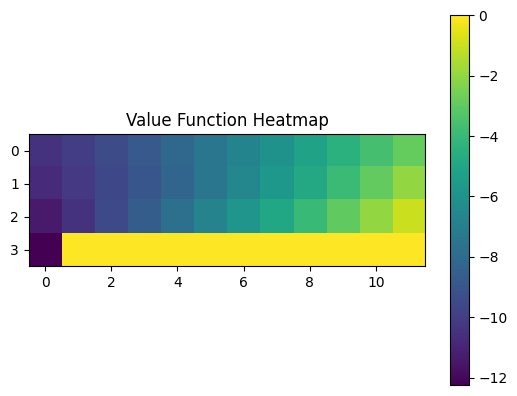

In [36]:
plot_heatmap(Q_sarsa, env)
plot_heatmap(Q_q, env)

The heatmaps reinforce these observations. For Q-learning, higher values are concentrated along the optimal path near the cliff, indicating that the agent strongly values these states despite their risk. For SARSA, the values near the cliff are lower, showing that the agent assigns less importance to risky states and instead prefers safer regions of the grid.

# POLICY

In [25]:
def plot_policy(Q):
    policy = np.argmax(Q, axis=1).reshape((4, 12))
    print(policy)

In [26]:
env_name = "CliffWalking-v0"

sarsa_rewards = run_experiment("sarsa", env_name)
q_rewards = run_experiment("q", env_name)

In [40]:
env = gym.make("CliffWalking-v0")

Q_sarsa, _ = run_sarsa(env, 500, 0.1, 0.99, 0.1)
Q_q, _ = run_q_learning(env, 500, 0.1, 0.99, 0.1)


plot_policy_arrows(Q_sarsa)
plot_policy_arrows(Q_q)


→ → → → → ← ↓ → → → ↓ ↓
→ → → → → → → → → → → ↓
↑ ↑ → ← ↑ ↑ ← → → ↑ → ↓
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
← ← → ↑ ↑ → ← → → → ↑ ↓
↑ → → ← ↓ ↓ → → → ↓ ↓ ↓
→ → → → → → → → → → → ↓
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑


The arrows frequently point right and downward, guiding the agent along the shortest path, even if it passes close to the cliff. This behavior reflects a more aggressive strategy focused on maximizing rewards.

In [28]:
def plot_trajectory(env, Q, epsilon=0.0):
    state, _ = env.reset()
    done = False
    trajectory = [state]

    while not done:
        action = np.argmax(Q[state]) 
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        trajectory.append(next_state)
        state = next_state

    grid = np.zeros(env.observation_space.n)
    for s in trajectory:
        grid[s] = 1

    grid = grid.reshape((4,12))
    plt.imshow(grid)
    plt.title("Trajectory")
    plt.show()

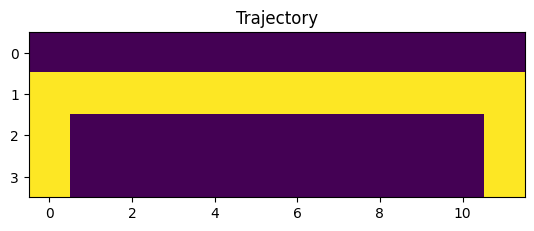

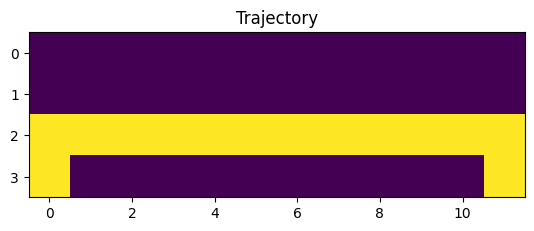

In [29]:
plot_trajectory(env, Q_sarsa)
plot_trajectory(env, Q_q)

- The trajectories confirm the behavioral differences between the algorithms.

- SARSA follows a safer path that keeps distance from the cliff, reducing the risk of large negative rewards.

- Q-learning takes a shorter and more direct path toward the goal, which is optimal but passes closer to the cliff, making it riskier.

### FINAL INSIGHT

This project highlights the fundamental trade-off between safety and optimality in reinforcement learning. SARSA, as an on-policy method, produces safer and more stable behavior by incorporating exploration into its updates. In contrast, Q-learning prioritizes optimality, achieving higher rewards but at the cost of increased risk during learning.
These findings demonstrate the importance of selecting the appropriate learning strategy depending on the problem context, particularly in environments where safety is a critical concern.